In [188]:
# Jupyter: 커널 → 재시작 및 모든 출력 지우기 후 실행
import tensorflow as tf
print("TF:", tf.__version__)   # 2.18.0

import keras
print("Keras:", keras.__version__)   # 3.x

TF: 2.21.0
Keras: 3.13.2


In [189]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'   # keras 호환 플래그 (맨 위에)

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Input, Dropout, Conv1DTranspose
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)   # 2.18.0 출력되면 정상

TensorFlow: 2.21.0


In [190]:
dir(pd)

['ArrowDtype',
 'BooleanDtype',
 'Categorical',
 'CategoricalDtype',
 'CategoricalIndex',
 'DataFrame',
 'DateOffset',
 'DatetimeIndex',
 'DatetimeTZDtype',
 'ExcelFile',
 'ExcelWriter',
 'Flags',
 'Float32Dtype',
 'Float64Dtype',
 'Grouper',
 'HDFStore',
 'Index',
 'IndexSlice',
 'Int16Dtype',
 'Int32Dtype',
 'Int64Dtype',
 'Int8Dtype',
 'Interval',
 'IntervalDtype',
 'IntervalIndex',
 'MultiIndex',
 'NA',
 'NaT',
 'NamedAgg',
 'Period',
 'PeriodDtype',
 'PeriodIndex',
 'RangeIndex',
 'Series',
 'SparseDtype',
 'StringDtype',
 'Timedelta',
 'TimedeltaIndex',
 'Timestamp',
 'UInt16Dtype',
 'UInt32Dtype',
 'UInt64Dtype',
 'UInt8Dtype',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__docformat__',
 '__file__',
 '__git_version__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_built_with_meson',
 '_config',
 '_is_numpy_dev',
 '_libs',
 '_pandas_datetime_CAPI',
 '_pandas_parser_CAPI',
 '_testing',
 '_typing',
 '_version_meson',
 'annota

In [191]:
vib_normal_ds = pd.read_csv("data/vibration_normal.csv")
vib_normal_ds.describe()

,0,3.12,6.25,9.38,12.5,15.62,18.75,21.88,25,28.12,...,1568.75,1571.88,1575,1578.12,1581.25,1584.38,1587.5,1590.62,1593.75,1596.88
count,1.774000e+03,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,...,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000,1774.000000
mean,3.957833e-04,0.000739,0.000791,0.000755,0.000792,0.000819,0.000837,0.000875,0.000904,0.000923,...,0.000628,0.000628,0.000624,0.000621,0.000616,0.000602,0.000618,0.000628,0.000601,0.000422
std,4.696484e-04,0.000996,0.001285,0.000831,0.000618,0.000662,0.000699,0.000832,0.000838,0.000884,...,0.000386,0.000380,0.000381,0.000366,0.000367,0.000371,0.000395,0.000399,0.000390,0.000282
min,1.940000e-07,0.000026,0.000012,0.000013,0.000004,0.000035,0.000017,0.000019,0.000029,0.000013,...,0.000007,0.000013,0.000006,0.000011,0.000031,0.000002,0.000016,0.000023,0.000020,0.000008
25%,1.303137e-04,0.000370,0.000417,0.000396,0.000441,0.000466,0.000456,0.000480,0.000500,0.000503,...,0.000363,0.000358,0.000352,0.000364,0.000350,0.000342,0.000336,0.000356,0.000341,0.000229
50%,3.012655e-04,0.000592,0.000647,0.000636,0.000686,0.000705,0.000732,0.000766,0.000785,0.000789,...,0.000554,0.000558,0.000548,0.000551,0.000558,0.000531,0.000537,0.000556,0.000533,0.000367
75%,5.175687e-04,0.000914,0.000944,0.000919,0.000988,0.001021,0.001073,0.001112,0.001131,0.001164,...,0.000823,0.000814,0.000810,0.000800,0.000801,0.000772,0.000809,0.000802,0.000776,0.000550
max,1.014758e-02,0.034840,0.041001,0.022906,0.012550,0.010571,0.014022,0.017517,0.018805,0.017654,...,0.003332,0.002509,0.003065,0.002895,0.002429,0.002882,0.003529,0.003379,0.004185,0.003108


In [192]:
vib_anomaly_ds = pd.read_csv("data/vibration_anomaly.csv")
vib_anomaly_ds.describe()

,0,3.12,6.25,9.38,12.5,15.62,18.75,21.88,25,28.12,...,1568.75,1571.88,1575,1578.12,1581.25,1584.38,1587.5,1590.62,1593.75,1596.88
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,...,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.013786,0.029425,0.031593,0.024693,0.023838,0.021556,0.022704,0.015820,0.013257,0.012501,...,0.023955,0.023620,0.020946,0.016045,0.021779,0.020399,0.017980,0.017234,0.019069,0.014062
std,0.015679,0.018364,0.019084,0.017172,0.017896,0.011829,0.013280,0.007814,0.010639,0.008008,...,0.017704,0.019947,0.019696,0.012145,0.021760,0.016615,0.015658,0.013074,0.015670,0.013213
min,0.000129,0.004947,0.006308,0.007834,0.003561,0.005212,0.007362,0.004388,0.001583,0.004308,...,0.003080,0.003761,0.002089,0.000641,0.001255,0.004353,0.001132,0.003172,0.001718,0.001196
25%,0.002406,0.020330,0.020912,0.011799,0.007745,0.013450,0.011365,0.009997,0.006823,0.007331,...,0.013454,0.007610,0.008412,0.006145,0.006557,0.006781,0.006503,0.007454,0.005576,0.004136
50%,0.009300,0.023152,0.025838,0.019777,0.018592,0.020922,0.019479,0.014260,0.010458,0.010748,...,0.018730,0.017856,0.013623,0.014272,0.012990,0.015888,0.010892,0.010731,0.012972,0.009364
75%,0.016383,0.034432,0.040664,0.033167,0.040558,0.028617,0.031699,0.022836,0.017115,0.013785,...,0.028388,0.030369,0.024991,0.025917,0.029100,0.030651,0.028372,0.024154,0.028106,0.019327
max,0.049609,0.072430,0.076610,0.061570,0.055249,0.043330,0.049333,0.029236,0.044670,0.035102,...,0.061035,0.068041,0.073223,0.042987,0.064231,0.057243,0.044247,0.043027,0.054982,0.047196


In [193]:
cur_normal_ds = pd.read_csv("data/current_normal.csv")
cur_normal_ds.head()

,Time,0,1.91,3.81,5.72,7.63,9.54,11.44,13.35,15.26,...,1933.93,1935.83,1937.74,1939.65,1941.56,1943.46,1945.37,1947.28,1949.19,1951.09
0,2021-09-01 0:04,0.028044,0.033194,0.023135,0.019984,0.012384,0.015154,0.003928,0.002710,0.001608,...,0.000641,0.000434,0.000695,0.000511,0.000566,0.000929,0.000841,0.000147,0.000633,0.000309
1,2021-09-01 0:07,0.017024,0.061488,0.025492,0.019490,0.003985,0.000198,0.001219,0.000958,0.000525,...,0.000394,0.000437,0.000833,0.001000,0.001070,0.000533,0.000425,0.000545,0.000734,0.000580
2,2021-09-01 0:10,0.055605,0.051026,0.033430,0.015864,0.010201,0.004803,0.001797,0.002638,0.002295,...,0.000610,0.000373,0.000331,0.000151,0.000219,0.000310,0.000346,0.000757,0.000883,0.000536
3,2021-09-01 0:17,0.070640,0.090214,0.061381,0.023377,0.018212,0.004499,0.001965,0.002304,0.002807,...,0.000676,0.000503,0.000430,0.000347,0.000463,0.000607,0.000992,0.000579,0.000623,0.000383
4,2021-09-01 0:21,0.089390,0.101223,0.069492,0.029898,0.013571,0.007979,0.002882,0.003186,0.000395,...,0.000552,0.000507,0.000512,0.000557,0.000603,0.000919,0.000860,0.000146,0.000602,0.000272


In [194]:
cur_anomaly_ds = pd.read_csv("data/current_anomaly.csv")
cur_anomaly_ds.head()

,Time,0,1.91,3.81,5.72,7.63,9.54,11.44,13.35,15.26,...,1933.93,1935.83,1937.74,1939.65,1941.56,1943.46,1945.37,1947.28,1949.19,1951.09
0,2021-07-21 15:40,3.767835,4.020009,0.875950,6.156515,5.546138,3.100119,8.766246,1.633168,5.111375,...,0.088311,0.132539,0.089407,0.099254,0.234076,0.155161,0.215416,0.254271,0.246627,0.147443
1,2021-07-21 16:33,5.106608,12.013001,9.308904,5.215157,10.490317,2.403275,14.367259,14.665602,4.620723,...,0.304766,0.085849,0.090350,0.131499,0.067617,0.171688,0.103295,0.112468,0.171594,0.108564
2,2021-07-21 19:58,5.747002,12.725037,10.936867,5.417918,6.302464,6.878624,6.669328,6.745722,6.463291,...,0.407950,0.380353,0.376850,0.331752,0.184041,0.163163,0.248755,0.190100,0.068477,0.089433
3,2021-07-22 13:19,6.930827,9.550858,12.423865,5.608191,4.370304,2.212492,2.340739,2.469330,6.216851,...,0.085864,0.120988,0.185122,0.075912,0.097762,0.065786,0.023454,0.141953,0.200623,0.054378
4,2021-07-22 13:25,2.577766,8.017437,5.942433,8.286139,6.780290,5.479986,5.983894,6.516971,5.466931,...,0.197637,0.298523,0.180578,0.121295,0.091325,0.079708,0.164527,0.270300,0.144208,0.174007


In [ ]:
# 이 데이터는 비지도학습!!!
# 진동에서의 정상, 비정상 데이터 : vib_normal_ds, vib_anomaly_ds
# 정상 데이터   행 1,774개, 컬럼 512개(맨 앞 컬럼은 시간 구분으로 제외)
# 비정상 데이터  행   16개, 컬럼 512개
# 학습데이터와 평가데이터를 구분해야하는데, 정상데이터에서 16개를 추출한 후, 비정상 데이터 16개와 합쳐서 평가데이터로 활용할 수 있다.
 
# 전류에서의 정상, 비정상 데이터 : cur_normal_ds, cur_anomaly_ds
# 정상데이터 행 8,202개, 컬럼 1,025개
# 비정상 데이터 행 32개, 컬럼 1,025개
# 진동 데이터와 마찬가지로, 정상데이터에서 32개를 추출한 후, 비정상 데이터 32개와 합쳐서 평가데이터로 활용할 수 있다.

In [195]:
print(vib_normal_ds.shape)
print(vib_anomaly_ds.shape)
print(cur_normal_ds.shape)
print(cur_anomaly_ds.shape)


(1774, 513)
(16, 513)
(8202, 1025)
(32, 1025)


In [196]:
# 진동 학습데이터
vib_train_ds = vib_normal_ds.iloc[:1758, 1:]
vib_train_ds.shape

# 진동 평가데이터
vib_test_ds = pd.concat([vib_normal_ds.iloc[1758:, 1:], vib_anomaly_ds.iloc[:, 1:]])
vib_test_ds.shape

print('진동 합습데이터 :', vib_train_ds.shape)
print('진동 평가데이터 :', vib_test_ds.shape)

진동 합습데이터 : (1758, 512)
진동 평가데이터 : (32, 512)


In [197]:
# 전류 학습데이터
cur_train_ds = cur_normal_ds.iloc[:8170, 1:]
cur_train_ds.shape

# 전류 평가데이터
cur_test_ds = pd.concat([cur_normal_ds.iloc[8170:, 1:], cur_anomaly_ds.iloc[:, 1:]])
cur_test_ds.shape

print('전류 합습데이터 :', cur_train_ds.shape)
print('전류 평가데이터 :', cur_test_ds.shape)

전류 합습데이터 : (8170, 1024)
전류 평가데이터 : (64, 1024)


In [199]:
# 데이터 전처리
# from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
vib_train_ds_scaled = scaler.fit_transform(vib_train_ds)
vib_test_ds_scaled = scaler.transform(vib_test_ds)
cur_train_ds_scaled = scaler.fit_transform(cur_train_ds)
cur_test_ds_scaled = scaler.transform(cur_test_ds)

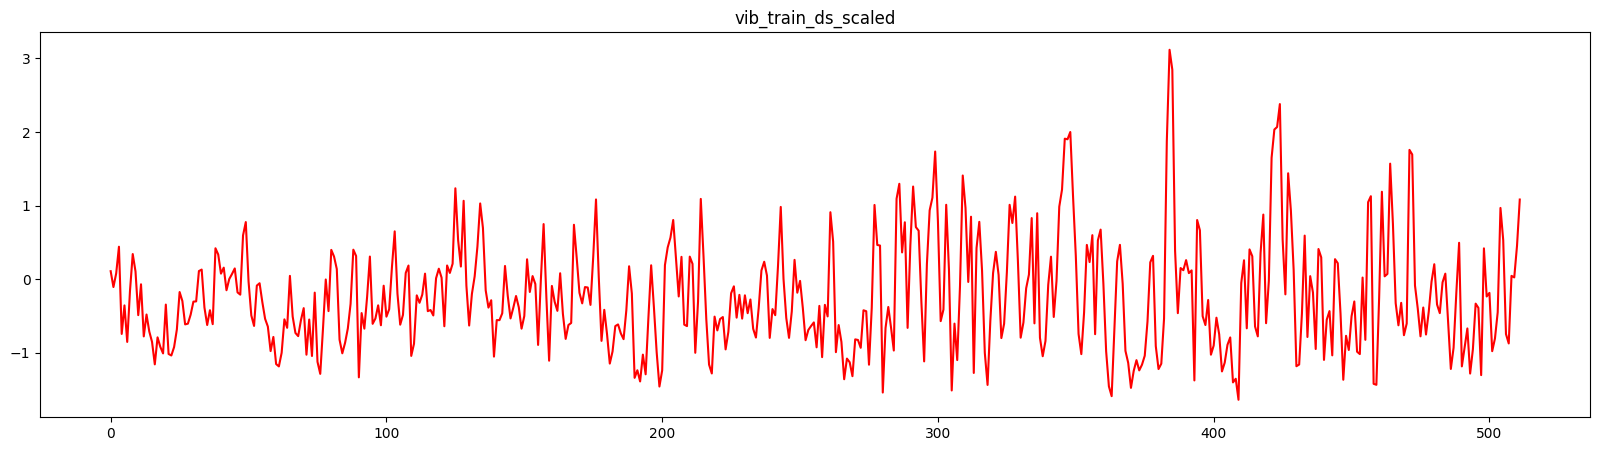

In [200]:
# 진동 학습데이터 시각화
plt.figure(figsize=(20, 5))
plt.title('vib_train_ds_scaled')
plt.plot(vib_train_ds_scaled[0], color="red")
plt.show()

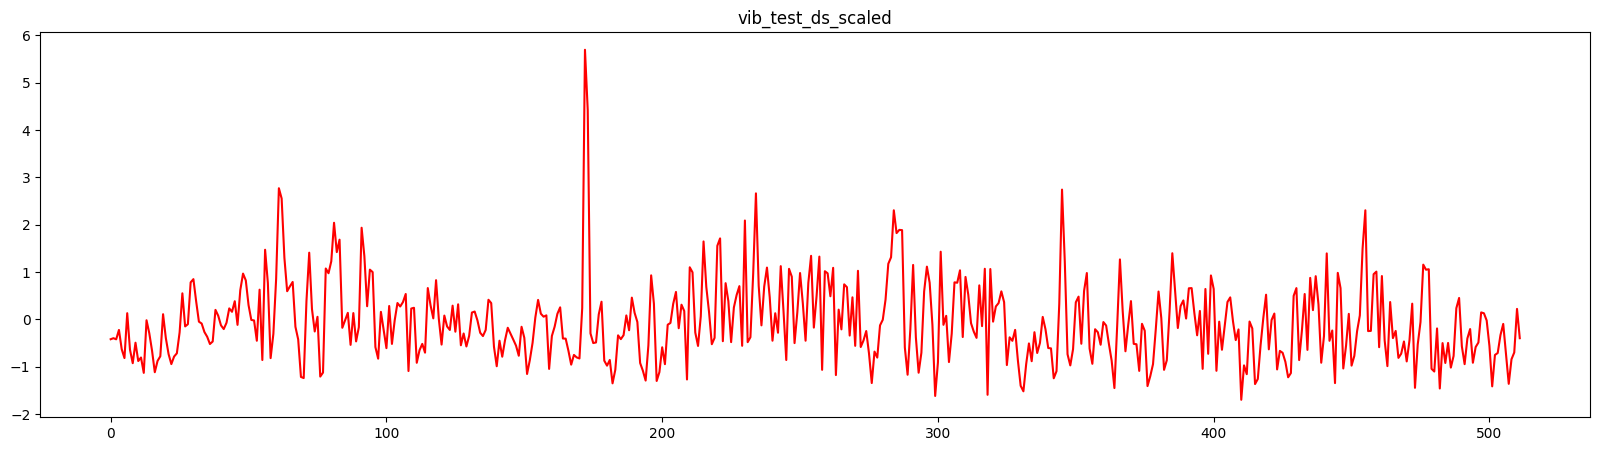

In [201]:
# 진동 평가데이터 시각화
plt.figure(figsize=(20, 5))
plt.title('vib_test_ds_scaled')
plt.plot(vib_test_ds_scaled[0], color="red")
plt.show()

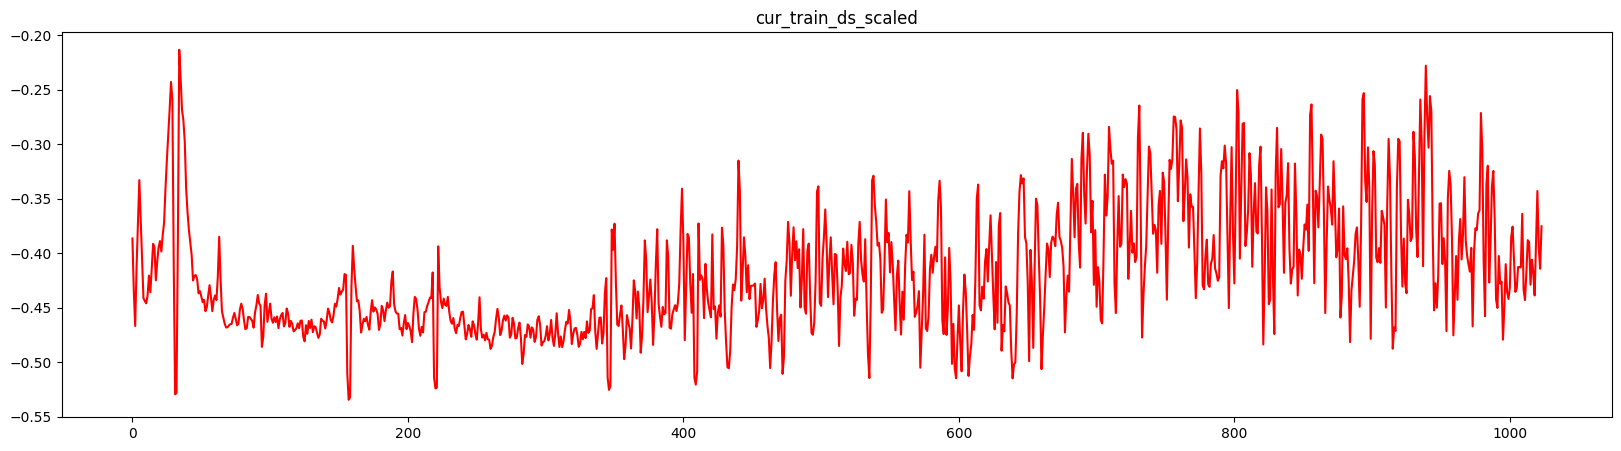

In [202]:
# 전류 학습데이터 시각화
plt.figure(figsize=(20, 5))
plt.title('cur_train_ds_scaled')
plt.plot(cur_train_ds_scaled[0], color="red")
plt.show()

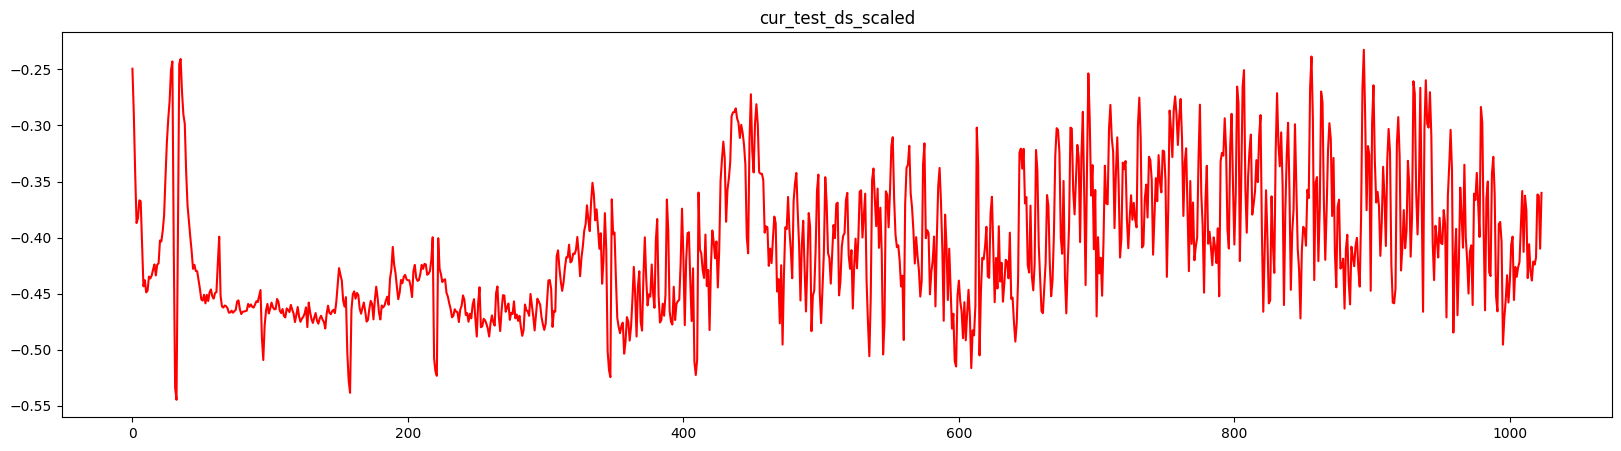

In [203]:
# 전류 평가데이터 시각화
plt.figure(figsize=(20, 5))
plt.title('cur_test_ds_scaled')
plt.plot(cur_test_ds_scaled[0], color="red")
plt.show()

In [204]:
# 학습, 평가 데이터 shape 확인
print('진동 학습데이터 shape :', vib_train_ds_scaled.shape)
print('진동 평가데이터 shape :', vib_test_ds_scaled.shape)
print('전류 학습데이터 shape :', cur_train_ds_scaled.shape)
print('전류 평가데이터 shape :', cur_test_ds_scaled.shape)

진동 학습데이터 shape : (1758, 512)
진동 평가데이터 shape : (32, 512)
전류 학습데이터 shape : (8170, 1024)
전류 평가데이터 shape : (64, 1024)


In [205]:
type(vib_train_ds.values)

numpy.ndarray

In [206]:
type(vib_test_ds.values)

numpy.ndarray

In [207]:
type(cur_train_ds.values)

numpy.ndarray

In [214]:
type(cur_test_ds)

pandas.DataFrame

In [217]:
# 모델링
# Conv_AE 모델링 하기 위해선 shape을 reshape 해줘야 한다
# print(vib_train_ds.shape)  
# print(vib_train_ds.values.shape) >>>>>>>> Cone 모델링에서는 숫자로만 받야해서 이렇게 바꿔줘야함

#(Pandas -> NumPy 3D)
vib_train_ds_reshaped = vib_train_ds.values.reshape(vib_train_ds.shape[0], vib_train_ds.shape[1], 1)
vib_test_ds_reshaped = vib_test_ds.values.reshape(vib_test_ds.shape[0], vib_test_ds.shape[1], 1)
cur_train_ds_reshaped = cur_train_ds.values.reshape(cur_train_ds.shape[0], cur_train_ds.shape[1], 1)
cur_test_ds_reshaped = cur_test_ds.values.reshape(cur_test_ds.shape[0], cur_test_ds.shape[1], 1)

# vib_train_ds = vib_train_ds.reshape(vib_train_ds.values.shape[0], vib_train_ds.values.shape[1], 1)    
# vib_test_ds = vib_test_ds.values.reshape(vib_test_ds.shape[0], vib_test_ds.shape[1], 1)    
# cur_train_ds = cur_train_ds.values.reshape(cur_train_ds.shape[0], cur_train_ds.shape[1], 1)
# cur_test_ds = cur_test_ds.values.reshape(cur_test_ds.shape[0], cur_test_ds.shape[1], 1)  

In [220]:
type(vib_train_ds_reshaped)

numpy.ndarray

In [221]:
def Conv_AE(input_ds):
    model = Sequential()
    model.add(Input(shape=(input_ds.shape[1], input_ds.shape[2])))
    model.add(Conv1D(filters=64, kernel_size=input_ds.shape[1]//64, padding="same", strides=2, activation="relu"))
    model.add(Conv1D(filters=32, kernel_size=input_ds.shape[1]//64, padding="same", activation="relu"))
    model.add(Conv1DTranspose(filters=64, kernel_size=input_ds.shape[1]//64, padding="same", strides=2, activation="relu"))
    model.add(Conv1DTranspose(filters=1, kernel_size=input_ds.shape[1]//64, padding="same"))

    return model

In [223]:
vib_model=Conv_AE(vib_train_ds_reshaped)
vib_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 256, 64)        │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 256, 32)        │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 512, 64)        │        16,448 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_3              │ (None, 512, 1)         │           513 │
│ (Conv1DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,953 (132.63 KB)

 Trainable params: 33,953 (132.63 KB)

 Non-trainable params: 0 (0.00 B)

In [225]:
cur_model=Conv_AE(cur_train_ds_reshaped)
cur_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 512, 64)        │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 512, 32)        │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_6              │ (None, 1024, 64)       │        32,832 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_7              │ (None, 1024, 1)        │         1,025 │
│ (Conv1DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,745 (264.63 KB)

 Trainable params: 67,745 (264.63 KB)

 Non-trainable params: 0 (0.00 B)

In [228]:
vib_model.compile(loss="mae", optimizer="adam")
vib_history = vib_model.fit(x=vib_train_ds_reshaped, y=vib_train_ds_reshaped, epochs=100, validation_split=0.2, callbacks=[EarlyStopping(monitor="val_loss", patience=10)])

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.9469e-04 - val_loss: 3.8058e-04
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.4113e-04 - val_loss: 3.4548e-04
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.7972e-04 - val_loss: 2.2016e-04
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.2903e-04 - val_loss: 1.5687e-04
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2912e-04 - val_loss: 7.5278e-05
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.0207e-04 - val_loss: 1.9329e-04
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2430e-04 - val_loss: 1.4110e-04
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0102e-04 - val_loss: 9.6312e-05
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.5750e-05 - val_loss: 6.9821e-05
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.5473e-05 - val_loss: 7.0933e-05
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.0930e-0

In [238]:
cur_model.compile(loss="mae", optimizer="adam")
cur_history = cur_model.fit(x=cur_train_ds_reshaped, y=cur_train_ds_reshaped, epochs=100, validation_split=0.2, callbacks=[EarlyStopping(monitor="val_loss", patience=10)])

Epoch 1/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 0.0082 - val_loss: 0.0028
Epoch 2/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - loss: 0.0028 - val_loss: 0.0061
Epoch 3/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 4/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 0.0022 - val_loss: 0.0077
Epoch 5/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 0.0022 - val_loss: 0.0015
Epoch 6/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - loss: 0.0019 - val_loss: 0.0054
Epoch 7/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 0.0017 - val_loss: 0.0057
Epoch 8/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 0.0022 - val_loss: 0.0044
Epoch 9/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 10/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 0.0015 - val_loss: 0.0021
Epoch 11/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 12/100
205/205 ━━━━━━

In [231]:
vib_history.history["loss"]

[0.0004946892731823027,
 0.0003411280340515077,
 0.00027971918461844325,
 0.00022903078934177756,
 0.0001291152584599331,
 0.00020207134366501123,
 0.00012429746857378632,
 0.0001010157575365156,
 7.575014024041593e-05,
 7.547330460511148e-05,
 7.093046588124707e-05,
 6.724524428136647e-05,
 6.77412172080949e-05,
 7.101135270204395e-05,
 6.597870378755033e-05,
 6.407868932001293e-05,
 6.328136078082025e-05,
 6.128835957497358e-05,
 9.068631334230304e-05,
 7.714685489190742e-05,
 6.128986569819972e-05,
 6.241816299734637e-05,
 5.981676440569572e-05,
 6.149948603706434e-05,
 6.006700641592033e-05,
 5.987578697386198e-05,
 5.95642086409498e-05,
 5.961685019428842e-05]

In [232]:
vib_history.history["val_loss"]

[0.0003805779851973057,
 0.00034548307303339243,
 0.00022016455477569252,
 0.00015686794358771294,
 7.527765410486609e-05,
 0.00019329244969412684,
 0.00014110236952546984,
 9.631160355638713e-05,
 6.982056220294908e-05,
 7.093308522598818e-05,
 9.477906132815406e-05,
 8.127337059704587e-05,
 0.00010903929796768352,
 9.001136641018093e-05,
 5.714410508517176e-05,
 6.554699211847037e-05,
 6.95879862178117e-05,
 5.515563680091873e-05,
 0.00014148271293379366,
 6.562317139469087e-05,
 6.68624707031995e-05,
 6.502352334791794e-05,
 6.632530858041719e-05,
 5.899637471884489e-05,
 7.243812433443964e-05,
 6.410551577573642e-05,
 6.818099791416898e-05,
 7.269721390912309e-05]

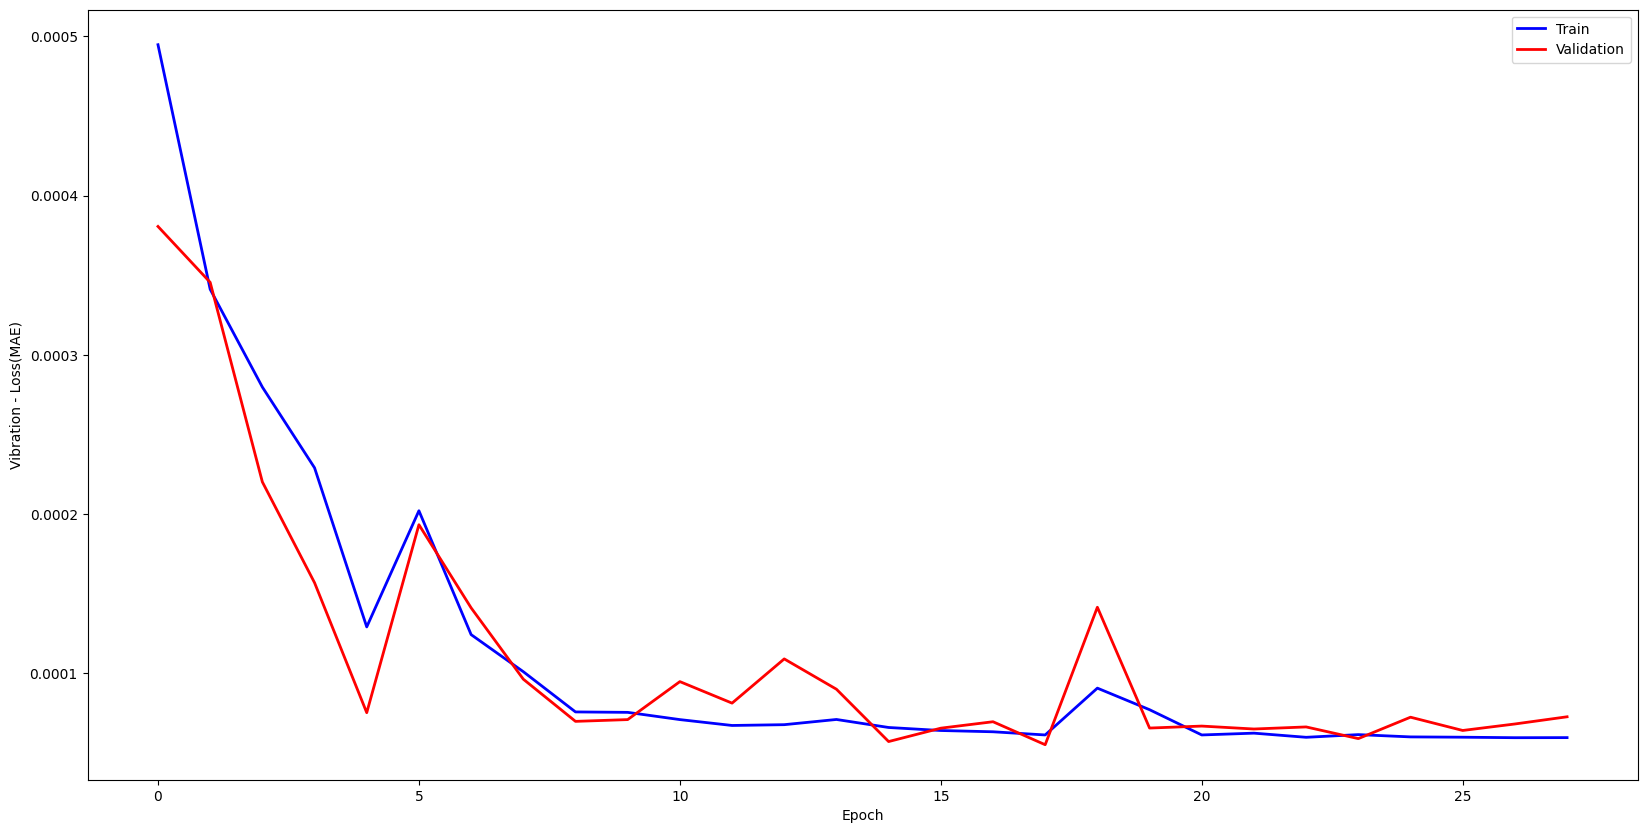

In [233]:
plt.figure(figsize=(20, 10))
plt.plot(vib_history.history["loss"], color="blue", label="Train", linewidth=2)
plt.plot(vib_history.history["val_loss"], color="red", label="Validation", linewidth=2)
plt.ylabel("Vibration - Loss(MAE)")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [235]:
cur_history.history["loss"]

[0.0004015776503365487,
 0.0003478974394965917,
 0.00034798806882463396,
 0.00034831042285077274,
 0.0003477815189398825,
 0.0003472942626103759,
 0.0003483451728243381,
 0.00034820905420929193,
 0.00035032365121878684,
 0.00035001279320567846,
 0.0003542511258274317]

In [236]:
cur_history.history["val_loss"]

[0.00038097036303952336,
 0.00038212721119634807,
 0.0003815526142716408,
 0.0003851413493975997,
 0.000381499994546175,
 0.00038190913619473577,
 0.0003827730834018439,
 0.0003980253532063216,
 0.0003811311034951359,
 0.0003826224128715694,
 0.000390806351788342]

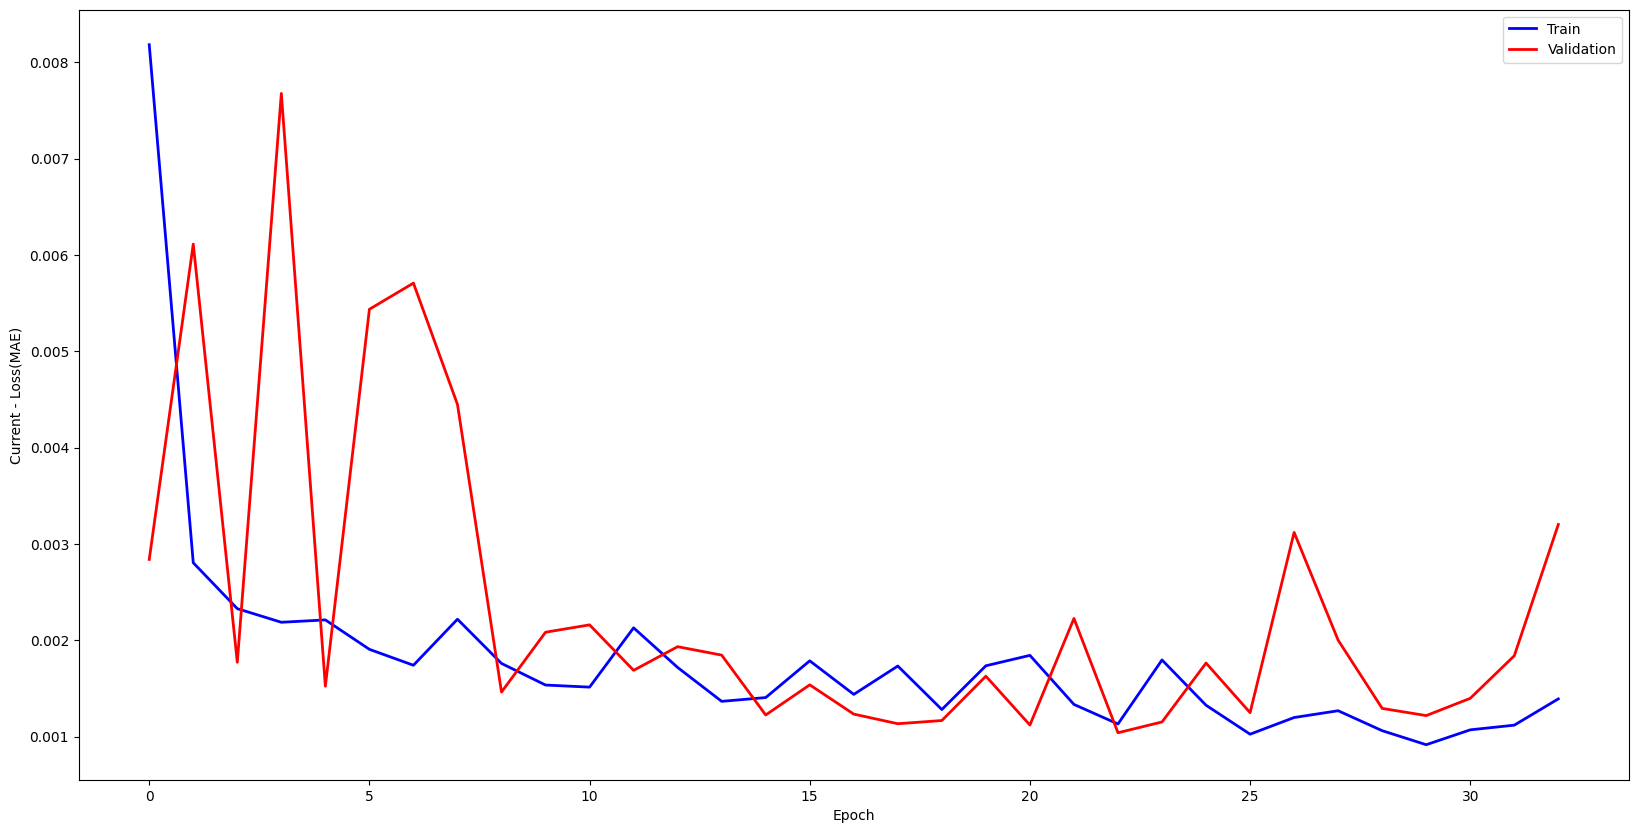

In [239]:
plt.figure(figsize=(20, 10))
plt.plot(cur_history.history["loss"], color="blue", label="Train", linewidth=2)
plt.plot(cur_history.history["val_loss"], color="red", label="Validation", linewidth=2)
plt.ylabel("Current - Loss(MAE)")
plt.xlabel("Epoch")
plt.legend()
plt.show()